# Fake News EDA
This notebook explores the WELFake dataset, comparing linguistic 
features between real and fake news articles through visualization.

**Sections:**
- Dataset overview
- Word count analysis
- Punctuation patterns
- Readability scores
- Sentiment analysis (VADER)
- Top words by news type

**Label encoding:** 0 = Real News, 1 = Fake News

In [16]:
# Imports
import os
import pandas as pd
import numpy as np
from textblob import TextBlob
import textstat
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv('../DATA/WELFake_Dataset.csv')

# preview the df
print(df.head())

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  


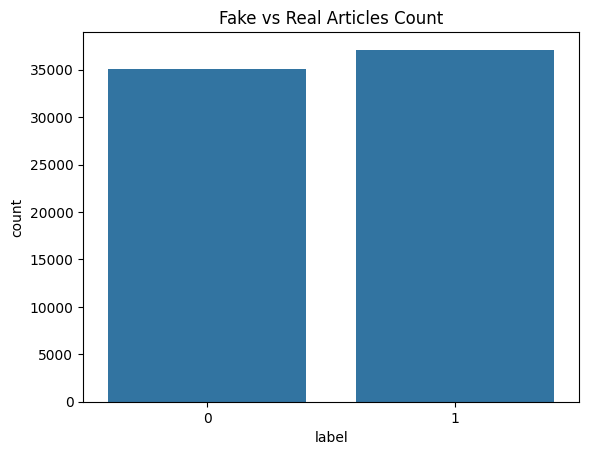

In [17]:
# Plot count of fake vs real articles, add title, and save figure
sns.countplot(x="label", data=df)
plt.title("Fake vs Real Articles Count")
plt.savefig("../OUTPUT/fake_vs_real_count.png", dpi=300, bbox_inches="tight")
plt.show()

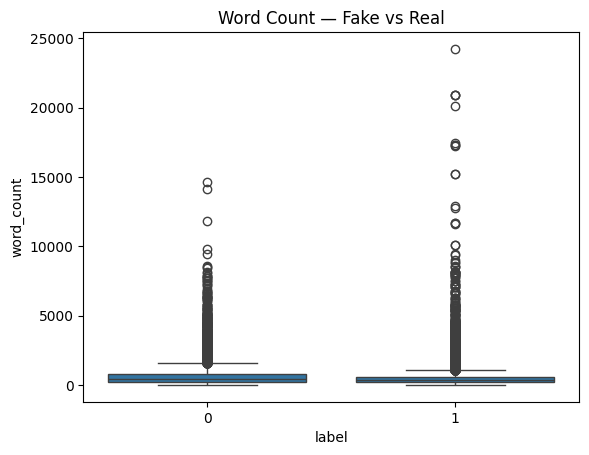

In [18]:
# Calculate word and character counts
df["word_count"] = df["text"].apply(lambda t: len(str(t).split()))
df["char_count"] = df["text"].apply(lambda t: len(str(t)))

# plot comparing word count for fake vs real articles, add title, and save figure
sns.boxplot(x="label", y="word_count", data=df)
plt.title("Word Count — Fake vs Real")
plt.savefig("../OUTPUT/fake_vs_real_word_count.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
#top word counts from fake and real news articles
df_clean = df.dropna(subset=["text"])

# Separate fake and real article text
fake_text = df_clean[df_clean["label"] == 1]["text"]
real_text = df_clean[df_clean["label"] == 0]["text"]

# Create vectorizer to get top 20 words
cv = CountVectorizer(stop_words="english", max_features=20)

# Get word counts for fake articles
fake_counts = cv.fit_transform(fake_text)
fake_words = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": fake_counts.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

# Get word counts for real articles
real_counts = cv.fit_transform(real_text)
real_words = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": real_counts.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

# Display top words in fake and real articles
fake_words, real_words


(          word   count
 17       trump  106364
 14        said   49712
 12      people   48653
 1      clinton   45411
 13   president   38982
 6         just   34612
 7         like   31766
 5      hillary   31592
 11       obama   28615
 9          new   28334
 16        time   26155
 15       state   25340
 2       donald   24955
 10        news   21866
 0     american   20847
 8        media   20393
 3     election   20309
 4   government   20190
 19       world   19811
 18       white   19445,
           word   count
 12        said  184607
 17       trump  107201
 5           mr   66086
 9    president   51300
 6          new   42528
 8       people   41792
 13       state   38871
 14      states   31668
 2   government   30110
 11     reuters   29342
 3        house   28578
 1      clinton   28569
 19        year   28154
 18      united   27740
 10  republican   26548
 4         like   24796
 16        told   23991
 0     campaign   23383
 15        time   23335
 7        obama

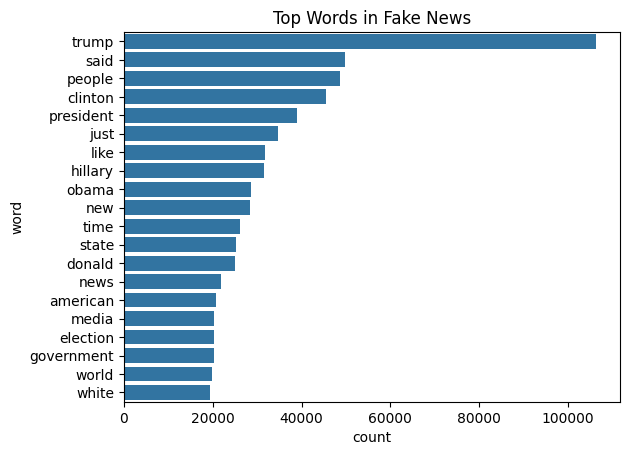

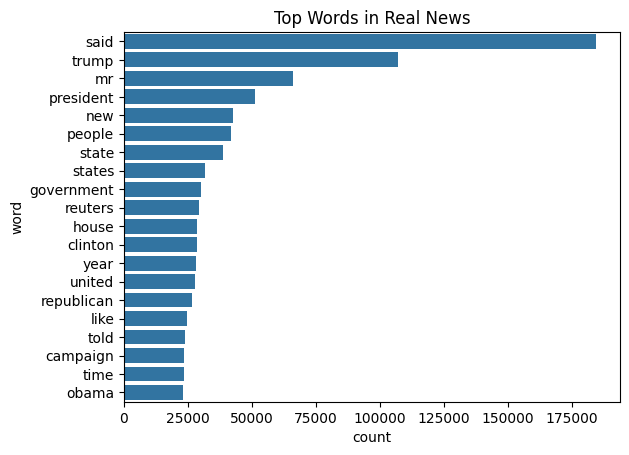

In [20]:
#plots of word counts for fake and real words, each plot is saved
sns.barplot(
    data=fake_words,
    x="count",
    y="word"
)
plt.title("Top Words in Fake News")
plt.savefig("../OUTPUT/fake_news_top_words.png", dpi=300, bbox_inches="tight")
plt.show()


sns.barplot(
    data=real_words,
    x="count",
    y="word"
)
plt.title("Top Words in Real News")
plt.savefig("../OUTPUT/real_news_top_words.png", dpi=300, bbox_inches="tight")
plt.show()


In [21]:
sample_size = 10000  # total sample size

# Create balanced sample with equal fake and real articles
# Create balanced sample with equal fake and real articles
fake_sample = df_clean[df_clean["label"] == 1].sample(sample_size // 2, random_state=42)
real_sample = df_clean[df_clean["label"] == 0].sample(sample_size // 2, random_state=42)
df_sample = pd.concat([fake_sample, real_sample]).reset_index(drop=True)


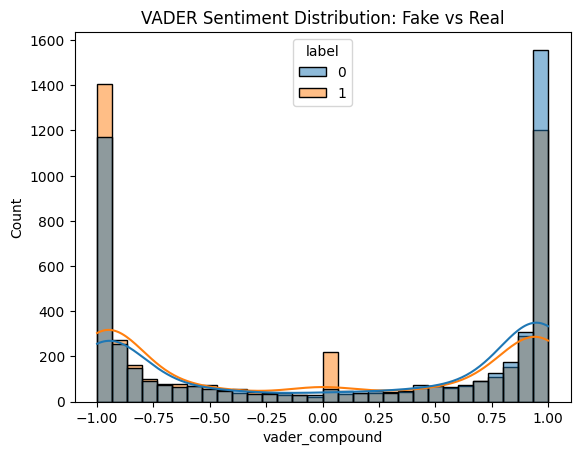

In [22]:
#sentiment analysis
analyzer = SentimentIntensityAnalyzer()

# Calculate sentiment score (compound score) for each article
df_sample["vader_compound"] = df_sample["text"].apply(lambda t: analyzer.polarity_scores(t)["compound"])

# Plot sentiment score distribution for fake vs real news
sns.histplot(
    data=df_sample,
    x="vader_compound",
    hue="label",
    bins=30,
    kde=True
)

# Add title and save figure
plt.title("VADER Sentiment Distribution: Fake vs Real")
plt.savefig("../OUTPUT/vader_sentiment_dist_fake_vs_real.png", dpi=300, bbox_inches="tight")


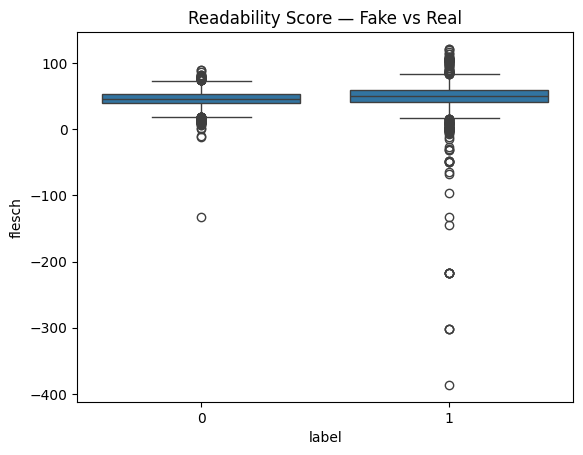

In [23]:
# Calculate readability score using Flesch Reading Ease
df_sample["flesch"] = df_sample["text"].apply(lambda t: textstat.flesch_reading_ease(str(t)))

# Create boxplot comparing readability of fake vs real news and save figure
plt.title("Readability Score — Fake vs Real")
sns.boxplot(x="label", y="flesch", data=df_sample)
plt.savefig("../OUTPUT/readability_real_vs_fake.png", dpi=300, bbox_inches="tight")

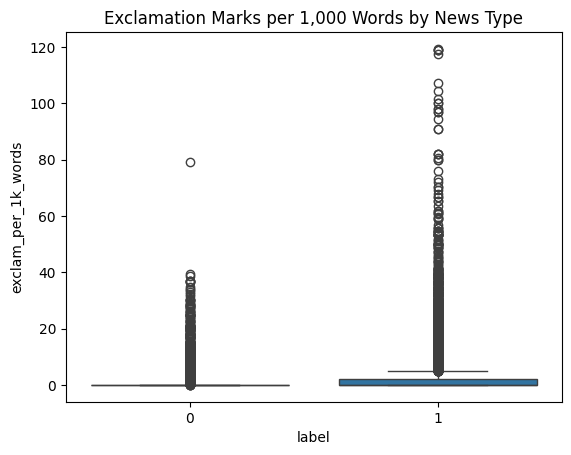

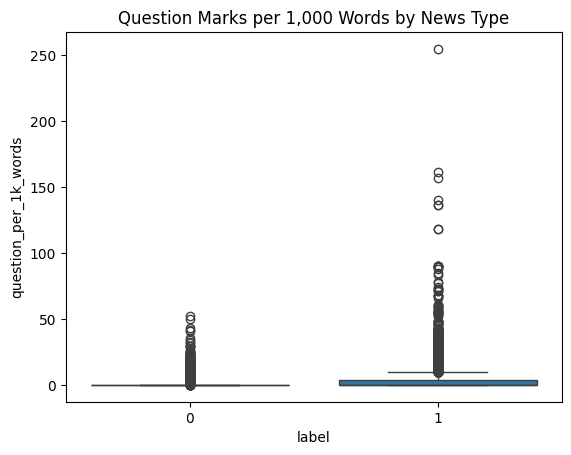

In [24]:
# Keep articles with at least 50 words and count the number of ! and ?
df_clean["word_count"] = df_clean["text"].apply(lambda t: len(str(t).split()))
df_clean = df_clean[df_clean["word_count"] >= 50]
df_clean["exclamations"] = df_clean["text"].apply(lambda t: str(t).count("!"))
df_clean["questions"] = df_clean["text"].apply(lambda t: str(t).count("?"))

# Normalize exclamation marks per 1,000 words
df_clean["exclam_per_1k_words"] = (
    df_clean["exclamations"] / df_clean["word_count"]
) * 1000

# Normalize question marks per 1,000 words
df_clean["question_per_1k_words"] = (
    df_clean["questions"] / df_clean["word_count"]
) * 1000

# Plot exclamation marks comparison between fake and real news and save the figure
sns.boxplot(
    x="label",
    y="exclam_per_1k_words",
    data=df_clean
)
plt.title("Exclamation Marks per 1,000 Words by News Type")
plt.savefig("../OUTPUT/exclamationmarks_by_news_type.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot question marks comparison between fake and real news and save the figure
sns.boxplot(
    x="label",
    y="question_per_1k_words",
    data=df_clean
)
plt.title("Question Marks per 1,000 Words by News Type")
plt.savefig("../OUTPUT/questionmarks_by_news_type.png", dpi=300, bbox_inches="tight")
plt.show()
